In [1143]:
## Load my files ##
import sys
sys.path.append('..')
from utils import get_sequence

## Load standard files ##
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torch.optim.lr_scheduler as lr_scheduler
from torch import from_numpy as tnsr
from scipy.stats import bernoulli
import torch.nn as nn
import numpy as np
import pandas as pd
from tqdm import tqdm
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist as dist
from sklearn.metrics.pairwise import cosine_similarity
from scipy.signal import find_peaks
from scipy.spatial import distance
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

In [1224]:
n_community = 2
n_members = 3

tokens = []

for ii in range(n_community*n_members+1):
    tokens.append(
        chr(ord('A')+ii)
    )

In [1225]:
class brain(nn.Module):
    def __init__(self, input_size, hidden_wake_size, hidden_sleep_size, sleep_output_size, num_layers=2, num_layers_sleep=2):
        super(brain, self).__init__()

        self.rnn = nn.RNN(input_size+sleep_output_size, hidden_wake_size, num_layers, nonlinearity='relu', batch_first=True)
        self.sleep_rnn = nn.RNN(1, hidden_sleep_size, num_layers_sleep, nonlinearity='relu', batch_first=True)
        self.sleep_fc = nn.Linear(hidden_sleep_size, sleep_output_size)
        # self.fc = nn.Linear(hidden_wake_size, 15)
        self.wake_fc = nn.Linear(hidden_wake_size, len(tokens))
        self.sleep_output_size = sleep_output_size

    def forward(self, x, x_=None, hw=None, hs=None, sleep=False):
        # print(x.shape, 'x')
        if sleep:
            if hs == None:
                out, hs = self.sleep_rnn(x_)
            else:
                out, hs = self.sleep_rnn(x_, hs)
            # print(out.shape)
            sleep_out = self.sleep_fc(out)
        else:
            sleep_out = torch.zeros((1,x.size(1),self.sleep_output_size))
            
        # print(x.size())
        x = torch.cat((x,sleep_out), dim=2)
        
        if hw == None:
            out, hw = self.rnn(x)
        else:
            out, hw = self.rnn(x, hw)

        # out_ = self.fc(out) 
        out = self.wake_fc(out[:,-1,:])

        if sleep:
            return out, hw, hs
        else:
            return out, hw

In [1226]:
def compute_geodesic(hidden1, hidden2):

    total_layers = len(hidden1)
    w = 0

    for ii in range(total_layers):
        w_ = np.array(dist( hidden1[ii], hidden2[ii], 'cosine'))
        w += w_
           
    return w[0][0]/total_layers

In [1227]:
class Dataset_converter(Dataset):
    def __init__(self, data, working_memory=1, short_term_memory=8):
        
        one_hot_encoded = np.zeros((len(data), len(tokens)), dtype=float)
        for ii, token in enumerate(data):
            one_hot_encoded[ii,ord(token)-65] = 1
        
        self.X = np.zeros((((len(data)-working_memory-short_term_memory)), short_term_memory, len(tokens)*working_memory))
        self.y = np.zeros((((len(data)-working_memory-short_term_memory)), len(tokens)))

        for ii in range(self.X.shape[0]):
            for jj in range(self.X.shape[1]):
                for kk in range(working_memory):
                    self.X[ii,jj,kk*len(tokens):(kk+1)*len(tokens)] = \
                    one_hot_encoded[ii+jj+kk,:]
                    
            self.y[ii] = \
                one_hot_encoded[ii+jj+kk+1,:]

        self.X = tnsr(self.X).float()
        self.y = tnsr(self.y).float()

    def __getitem__(self, index):
        return self.X[index], self.y[index]

    def __len__(self):
        return self.X.shape[0]

In [1228]:
### initial training ###
total_samples = 40000
working_memory = 1
short_term_memory = 1
hidden_wake_size = 30
hidden_sleep_size = 10
sleep_output_size = 5
num_layers_wake = 1
num_layers_sleep = 1
output_sleep = len(tokens)
input_size = len(tokens)*working_memory
lr = 4e-4
test_acc = []

data = get_sequence(total_samples, n_community, n_members, train_percent=1.0)

data_set = Dataset_converter(data, working_memory, short_term_memory)
train_loader = DataLoader(data_set, batch_size=1, shuffle=False)

network1 = brain(input_size, hidden_wake_size, hidden_sleep_size, sleep_output_size, num_layers_wake, num_layers_sleep)

optimizer = torch.optim.SGD(network1.parameters(), lr=lr, momentum=0.95)
criterion = torch.nn.CrossEntropyLoss()

total = 0
correct = np.zeros(1000,dtype=float)
for X, y in train_loader:
    optimizer.zero_grad()

    if total == 0:
        predicted_y, hidden = network1(X)
    else:
        predicted_y, hidden = network1(X, hw=mem)
    
    # print(predicted_y.shape, y.shape)
    loss = criterion(predicted_y, y)
    loss.backward(retain_graph=True)
    optimizer.step()

    with torch.no_grad():
        mem=hidden.clone()
        true_y = y.argmax(axis=1)
        estimated_y = predicted_y.argmax(axis=1)

        total += 1
        if true_y == estimated_y:
                correct[total%1000] = 1
        else:
            correct[total%1000] = 0

        test_acc.append(
            np.sum(correct)/total if total<1000 else np.sum(correct)/1000
        )
        if total%1000 == 0:
            print(f'Iter : {total+1}, loss: {loss:.4f}, accuracy: {test_acc[-1]:.4f}')

Iter : 1001, loss: 2.0938, accuracy: 0.2300
Iter : 2001, loss: 1.9199, accuracy: 0.2500
Iter : 3001, loss: 1.8041, accuracy: 0.3510
Iter : 4001, loss: 2.4419, accuracy: 0.4830
Iter : 5001, loss: 1.9765, accuracy: 0.5240
Iter : 6001, loss: 2.2596, accuracy: 0.5800
Iter : 7001, loss: 2.7922, accuracy: 0.6210
Iter : 8001, loss: 1.1316, accuracy: 0.6380
Iter : 9001, loss: 1.5268, accuracy: 0.6530
Iter : 10001, loss: 0.8220, accuracy: 0.6770
Iter : 11001, loss: 1.2449, accuracy: 0.6680
Iter : 12001, loss: 1.7610, accuracy: 0.6450
Iter : 13001, loss: 2.1953, accuracy: 0.6190
Iter : 14001, loss: 1.3111, accuracy: 0.6690
Iter : 15001, loss: 2.4824, accuracy: 0.6600
Iter : 16001, loss: 1.7302, accuracy: 0.6570
Iter : 17001, loss: 1.4430, accuracy: 0.6620
Iter : 18001, loss: 1.9224, accuracy: 0.6550
Iter : 19001, loss: 1.1270, accuracy: 0.6520
Iter : 20001, loss: 2.5509, accuracy: 0.6460
Iter : 21001, loss: 1.8497, accuracy: 0.6710
Iter : 22001, loss: 1.6677, accuracy: 0.6890
Iter : 23001, loss:

In [1232]:
centroids = []

total_samples = 1000
steps = 10
idx = torch.randint(0, len(tokens), (1,)) [0]
X_hat = torch.zeros(len(tokens),dtype=torch.float32)
X_hat[idx] = 1.0
counts = []

for jj in tqdm(range(total_samples)):
    with torch.no_grad():
        # print(tokens[idx])
        if jj == 0:
            X_hat, hidden_state = network1(X_hat.reshape(1,1,-1))
        else:
            X_hat, hidden_state = network1(X_hat.reshape(1,1,-1), hidden_state)

        # X_zero = torch.zeros(len(tokens),dtype=torch.float32)
        mem_ = hidden_state.clone() 
        for ii in range(steps):
            _, mem = network1(X_hat.reshape(1,1,-1), mem_)
            mem_ = mem

        flag = True
        for center in centroids:
            # print(torch.abs(torch.sum(mem-center)))
            if torch.abs(torch.sum(mem-center)).detach().numpy() < 1e-2:
                flag = False
        
        if flag:
            centroids.append(mem)

        X_hat = torch.nn.functional.softmax(X_hat, dim=1)
        dist_categ = torch.distributions.Categorical(probs=X_hat.reshape(-1))
        idx = dist_categ.sample()

        X_hat = torch.zeros(len(tokens),dtype=torch.float32)
        X_hat[idx] = 1.0
        X_hat = X_hat.reshape(1,1,-1)

        

100%|██████████| 1000/1000 [00:00<00:00, 2242.79it/s]


In [1233]:
len(centroids)

7

In [1231]:
centroids

[tensor([[[ 0.6865,  0.3307,  2.0968,  0.0000,  0.0000,  0.0000,  1.2152,
            0.3847,  0.3231,  0.0000,  1.0522,  0.0000,  0.0000,  0.1733,
            0.0000,  4.9440,  0.7403,  0.0000,  0.0000,  0.0000,  0.0000,
            0.0000,  0.2269,  5.3366,  0.0000,  0.0000,  0.0000,  0.0000,
           15.8107,  0.0000]]]),
 tensor([[[ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  4.9061,
            0.0000,  1.1176,  0.7247,  6.6165,  2.9428,  0.0000,  0.7107,
            3.6319,  0.0000,  1.0613,  5.3695,  0.9625,  0.0000,  3.9994,
            0.0000,  0.6392,  7.9056,  0.0000,  0.0000,  0.0000,  0.0000,
           19.2054,  0.0000]]]),
 tensor([[[ 0.0000,  0.0000,  2.9823,  0.0000,  0.0000,  0.3868,  3.1235,
            0.1973,  0.3412,  0.8988,  0.4399,  0.0000,  0.0000,  0.8126,
            2.2091,  1.8277,  0.4976,  0.0000,  0.0000,  0.0000,  0.2535,
            0.0000,  0.3707,  7.4081,  0.0000,  4.0292,  0.0000,  0.0000,
           17.5451,  0.0000]]]),
 tensor([[[ 0

In [1175]:
a = set()

In [1182]:
a.add(3)

In [1183]:
a

{2, 3}

In [1137]:
centroids = []

threshold = .2
n_samples = 50000
idx = torch.randint(0, len(tokens), (1,)) [0]
X_hat = torch.zeros(len(tokens),dtype=torch.float32)
X_hat[idx] = 1.0
counts = []

for ii in range(n_samples):
    if ii == 0:
        # seq += tokens[idx]        
        X_hat, mem = network1(X_hat.reshape(1,1,-1))
        centroids.append(mem[0][0])
        counts.append(1)
    else:
        X_hat, mem = network1(X_hat, mem)

    dis = []
    min_dis = 10
    min_dis_id = -1
    for jj in range(len(centroids)):
        dis.append(
            distance.cosine(centroids[jj].detach().numpy(), mem[0][0].detach().numpy())
        )
        if min_dis >= dis[-1]:
            min_dis = dis[-1] 
            min_dis_id = jj 
    if min_dis < threshold:
        centroids[min_dis_id] = (counts[min_dis_id]*centroids[min_dis_id] + mem[0][0]/torch.norm(mem[0][0],p=2))/(counts[min_dis_id]+1)
        counts[min_dis_id] += 1
    else:
        centroids.append(mem[0][0]/torch.norm(mem[0][0], p=2))
        counts.append(1)

    # print(min_dis)   
    X_hat = torch.nn.functional.softmax(X_hat, dim=1)
    dist_categ = torch.distributions.Categorical(probs=X_hat.reshape(-1))
    idx = dist_categ.sample()

    X_hat = torch.zeros(len(tokens),dtype=torch.float32)
    X_hat[idx] = 1.0
    X_hat = X_hat.reshape(1,1,-1)  

    # if idx==6:
    #     print(tokens[idx])
    # for ii, center in enumerate(centroids): 
    #     centroids[ii] = centroids[ii].detach().numpy()

In [1138]:
len(centroids)

7

In [1139]:
thresholds = np.arange(.1,2,.01)
diff_cluster_dis_list = []
same_cluster_dis_list = []

for threshold in tqdm(thresholds):
    mega_cluster = []
    # threshold = 0.75
    labels = [0]
    total_centroids = len(centroids)

    current_label = 0
    same_cluster_dis = [0]
    diff_cluster_dis = [0]
    flag = True
    for ii in range(1,total_centroids):
        for jj in range(ii-1,-1,-1):
            # print(distance.cosine(centroids[ii].detach().numpy(), centroids[jj].detach().numpy()), ii, jj)
            if distance.cosine(centroids[ii].detach().numpy(), centroids[jj].detach().numpy()) <= threshold:
                labels.append(labels[jj])
                flag = False
                break 
            
        if flag :
            current_label += 1
            labels.append(current_label)
        flag = True 

    for ii, center in enumerate(centroids):
        for jj, center_ in enumerate(centroids):
            if labels[ii] != labels[jj]:
                diff_cluster_dis.append(
                    distance.cosine(centroids[ii].detach().numpy(), centroids[jj].detach().numpy())
                )
            else:
                same_cluster_dis.append(
                    distance.cosine(centroids[ii].detach().numpy(), centroids[jj].detach().numpy())
                )

    diff_cluster_dis_list.append(
        np.mean(diff_cluster_dis) 
    )
    same_cluster_dis_list.append(
        np.mean(same_cluster_dis) 
    )
    # print(labels)
    # if len(diff_cluster_dis_list) > 1:
    #     if diff_cluster_dis_list[-1] <= diff_cluster_dis_list[-2]:
    #         break

# print(diff_cluster_dis_list)

100%|██████████| 190/190 [00:00<00:00, 1557.84it/s]


/var/folders/_7/jy1bxm8x25zgqldfzz7cqv8r0000gn/T/ipykernel_5636/1793084729.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


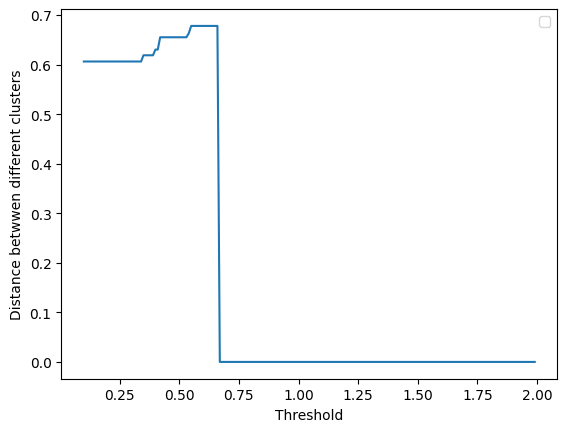

In [1140]:
plt.plot(thresholds, diff_cluster_dis_list)
# plt.plot(mask[-span:], c='k', label = 'mask')
plt.xlabel('Threshold')
plt.ylabel('Distance betwwen different clusters')
plt.legend()

In [1136]:
labels

[0, 0, 0, 1, 1, 1, 0]

In [1141]:
np.argmax(diff_cluster_dis_list)

45

In [1142]:
thresholds[45]

0.5499999999999998

In [ ]:
n_samples = 1000
data = get_sequence(total_samples, n_community, n_members, train_percent=1.0)

data_set = Dataset_converter(data, working_memory, short_term_memory)
train_loader = DataLoader(data_set, batch_size=1, shuffle=False)

community = {}
for ii in range(len(centroids)):
    community[ii] = []

ii = 0

for X, y in train_loader:
    if ii == 0:
        # seq += tokens[idx]        
        X_hat, mem = network1(X.reshape(1,1,-1))
        # centroids.append(mem[0][0])
    else:
        X_hat, mem = network1(X, mem)
    
    dis = []
    for center in centroids:
        dis.append(
            distance.cosine(center.detach().numpy(), mem[0][0].detach().numpy())
        )
    
    idx = np.argmin(dis)
    community[idx].append(tokens[X.argmax(axis=2)])

         
    ii += 1

In [1216]:
for com in community.keys():
    print(np.unique(community[com]))

['D']
['E' 'F']
[]
['A' 'G']
['C']
['B']
[]


In [44]:
data

'...'

In [76]:
centroids_ = []
for ii, center in enumerate(centroids): 
    centroids_.append(centroids[ii].detach().numpy())

In [77]:


model_compressor = LogisticRegression(multi_class='ovr', solver='lbfgs')
model_compressor.fit(centroids_, labels)


/Users/jayantadey/miniforge3/envs/torch/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(multi_class='ovr')

In [78]:
model_compressor.predict(centroids_)

array([0, 0, 1, 2, 0, 2, 2])